# 第2课 · 把空气的颤抖装进数组——采样（sampling）与你的第一声可听正弦波（sine wave）

**学习目标**
1. 理解采样：连续声音 → numpy 数组 → 可再生的声音
2. 实现 `samples_count`：N = duration × sample_rate
3. 实现 `make_time_axis`：生成时间轴
4. 能读懂 1D 信号的数组形状（shape）：知道 `(N,)` 与矩阵 `(M, N)` 有何不同（插曲里还有 30 秒口头题）
5. 实现 `make_sine`：生成正弦波并播放
6. 实现 `signal_summary`：汇总信号统计量

> 这四个函数是整个课程的「原子操作」——后续所有 notebook 都直接或间接调用它们。

← **上一课**　[L01 · 拒绝黑盒（动机与路线图）](L01_motivation.ipynb)

> 上节课建立了 **Aurora 的动机、6 个月路线图与环境自检**——为什么要从零写，以及接下来去哪。  
> 本课进入 **声音的数字表示**：采样、时间轴、第一声可听正弦波。

In [1]:
# 统一导入（运行整个 notebook 前请先执行此单元）
import numpy as np
import matplotlib.pyplot as plt
try:
    from IPython.display import Audio, display
except ImportError:
    pass

# ── 中文字体设置：防止图里的中文标题/坐标轴显示成方框（"豆腐块"）──
# matplotlib 默认字体 DejaVu Sans 不认识中文。下面从常见中文字体里
# 自动挑一个你电脑上真实安装的；如果图上中文仍是 □□□，把你系统里的
# 中文字体名加到列表最前面即可（Mac 常见 PingFang SC，Windows 常见
# SimHei / Microsoft YaHei，Linux 常见 Noto Sans CJK SC）。
from matplotlib import font_manager as _fm
_zh_candidates = ['Source Han Sans CN', 'Source Han Sans CN Normal', 'Arial Unicode MS',
                  'Heiti SC', 'SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC', 'WenQuanYi Micro Hei']
_installed = {f.name for f in _fm.fontManager.ttflist}
for _name in _zh_candidates:
    if _name in _installed:
        plt.rcParams['font.sans-serif'] = [_name] + plt.rcParams['font.sans-serif']
        break
plt.rcParams['axes.unicode_minus'] = False  # 顺带让坐标轴上的负号正常显示


## 本课学习方法：先手算，再让代码验证

Aurora 课程的核心方法不是「运行看输出」，而是：

```
① 拿到公式，先在纸上或 Markdown 里推导
② 用极小的例子（例如 duration=0.5s, sr=8Hz → N=4）手算结果
③ 写代码实现
④ 运行 assert，让代码和手算结果对答案
```

**为什么这样做？**  
面试中没有终端，只有白板。「先手算」的练习
练的就是让你在没有代码、只有一块白板时，也能自己把结果推出来。

本课每个任务都会先给一张推导表，等你填完再写代码。

## 1. 声音的物理本质

你有没有注意过，拨一根吉他弦时，空气会颤抖？

声音，本质上是空气**压强的波动**。吉他弦振动→推开附近空气分子→压强升高→传到你的耳膜→你听到了声音。麦克风做的事情完全一样：把空气压强的起伏，转成电压的起伏。

但"起伏"不能直接存进计算机。计算机只懂数字。

所以我们发明了**采样**（sampling）：每隔固定时间，量一次电压值，把它写成数字。这个"每隔多久量一次"就是**采样率**（sample rate，sr），单位是次/秒（Hz）。

CD 音质用 44100 Hz——每秒量 44100 次。人耳能听到的最高频率约 20000 Hz，根据奈奎斯特定理，采样率只需达到最高频率的 2 倍就能完整还原。44100 **略高于** $2 \times 20\,\mathrm{kHz} = 40\,\mathrm{kHz}$：既满足「不看错波」的物理下限，又给模拟抗混叠滤波器留出一点过渡带——既是物理需要，也叠了后面要讲的历史巧合。

```
采样率 sr = 44100 Hz
时长 duration = 1 秒
采样点数 N = round(duration × sr) = 44100 个数字
```

一秒音频 = 44100 个浮点数。这就是"数字声音"的本质。

---

### 追问一：为什么偏偏是"2 倍"？（先给直觉，L34 再做实验）

上面那句"根据奈奎斯特定理"听着像是不容置疑的圣旨——别急，我们把它翻译成人话。

一条波，每个周期里有一个波峰、一个波谷。要想不"看漏"这个周期，**每个周期至少得量到 2 个点**：一个逮住上半段、一个逮住下半段。换算一下：波每秒振 f 圈，你每秒就至少得量 2f 次——这就是"2 倍"的来源。

如果量得比这还稀会怎样？一条快波和一条慢波可能**穿过完全相同的采样点**。计算机拿到的数字一模一样，根本分不清你录的是哪条波——这个现象叫**混叠**（aliasing）。1.5 倍会漏（有些周期只摊到一个多点），3 倍当然更保险，只是更费存储，2 倍是"不看错"的最低门槛。

这里先建立直觉即可：**"每个周期至少 2 个点"**。完整的实验（亲眼看到两条不同的波穿过同一批点、亲耳听到高音"冒充"低音）在 **L34（aliasing）**那一课；本课稍后的演示格会先让你瞄一眼。

### 追问二：为什么是 44100，而不是整整齐齐的 44000？（选读；课末自评会回访）

**三行版**：按"只要 > 40000"的逻辑，44000、45000 都够用——44100 这个零碎的数主要是 **CD 时代迁就录像机磁带 / 电视行频** 凑出来的历史遗产，不是"算出来的最优整数"。课末自评会回访；想听完整故事再展开下面折叠。

<details>
<summary><b>展开：44100 从录像带里长出来的完整故事</b></summary>

CD 诞生之前，数字录音没有专门的存储介质，工程师借用**录像机的磁带**来存音频数据。为了让采样值恰好塞进电视信号的"行"里，采样率必须凑成电视制式参数的整数倍。巧的是，两大电视制式凑出了同一个数：

- 美制 NTSC：60 场/秒 × 245 行 × 每行存 3 个采样 = **44100**
- 欧制 PAL：50 场/秒 × 294 行 × 每行存 3 个采样 = **44100**

于是 44100 被写进 CD 标准，沿用至今。它不是算出来的"最优值"，而是老设备迁就出来的"够用值"。（顺带一提：44100 = 2²×3²×5²×7²，因数特别多，做整数倍降采样也方便。）

</details>

### 追问三：两个"Hz"不是一回事

马上你会遇到"8 Hz 采样率下的 1 Hz 正弦波"这种说法——两个 Hz 并排出现，很容易搅浑。它们计量的是两件不同的事：

- **采样率的 Hz**：每秒**量**多少次——相机快门每秒按几下
- **频率的 Hz**：声波每秒**振动**多少圈——被拍的物体转多快

一个是"观察的速度"，一个是"波本身的速度"。单位恰好都叫 Hz（每秒多少次），主语完全不同。

## ✏️ 任务 0：先手算 N，再实现 `samples_count`

**第一步：手算下表**（不要运行代码，用 `N = round(duration × sr)` 计算）

| duration (s) | sample_rate (Hz) | N（手算）|
|---|---|---|
| 0.5 | 8 | ✏️ ? |
| 1.0 | 16000 | ✏️ ? |
| 0.25 | 44100 | ✏️ ? |

**第二步**：填完表后再往下实现函数。

In [2]:
def samples_count(duration, sample_rate):
    """返回给定时长和采样率下的采样点总数 N。"""
    # ✏️ TODO: 返回 round(duration * sample_rate)
    raise NotImplementedError("TODO: 返回 round(duration * sample_rate)")

In [3]:
try:
    # 用代码对答案——和手算结果一致吗？
    assert samples_count(0.5, 8)     == 4,     f'期望 4，得到 {samples_count(0.5, 8)}'
    assert samples_count(1.0, 16000) == 16000, f'期望 16000，得到 {samples_count(1.0, 16000)}'
    assert samples_count(0.25, 44100)== round(0.25 * 44100)
    assert samples_count(1.0, 10)    == 10

    # 打印对照表
    print(f'  duration=0.5s,  sr=8     → N={samples_count(0.5, 8)}')
    print(f'  duration=1.0s,  sr=16000 → N={samples_count(1.0, 16000)}')
    print(f'  duration=0.25s, sr=44100 → N={samples_count(0.25, 44100)}')
    print('samples_count  OK')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


In [4]:
try:
    import numpy as np
    import matplotlib.pyplot as plt

    # 用 8 Hz 采样率采 0.5 秒：只有 4 个点，可以逐个检查
    sr, duration = 8, 0.5
    N = samples_count(duration, sr)
    t = np.arange(N) / sr
    x = np.sin(2 * np.pi * 1.0 * t)

    print(f'N = {N} 个点（{duration}s × {sr}Hz）')
    print(f't = {t}  （秒）')
    print(f'x = {np.round(x, 3)}  （采样值）')

    # 底下先垫一条"连续"的原始波形（用很密的点近似画出），
    # 这样能看清 4 个采样点是从哪条波上"摘"下来的
    t_dense = np.linspace(0, duration, 400)
    plt.plot(t_dense, np.sin(2 * np.pi * 1.0 * t_dense),
             color='0.75', lw=1.2, label='原始连续波形（空气的真实振动）')
    plt.stem(t, x, markerfmt='C0o', linefmt='C0-', basefmt='k-', label='采样点（存进计算机的数字）')
    plt.xlabel('时间 (s)'); plt.ylabel('振幅')
    plt.title(f'8 Hz 采样率下的 1 Hz 正弦波（N={N} 点）')
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout(); plt.show()
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


### 预告 L34：§1 说过的"看错波"——下面画出来

§1 追问一已经讲过直觉。这里不再重复定义，直接**画**：采样率还是 8 Hz，同时画一条 1 Hz 的慢波和一条 9 Hz 的快波——9 Hz 已经远超 8/2 = 4 Hz 的"安全线"。

**先预测再运行**：这两条波在 8 个采样时刻上取的值，会一样吗？

（本格不依赖你实现的函数，随时可以运行。完整听感实验在 **L34 aliasing**。）

1 Hz 在采样点上的值: [ 0.      0.7071  1.      0.7071  0.     -0.7071 -1.     -0.7071]
9 Hz 在采样点上的值: [ 0.      0.7071  1.      0.7071  0.     -0.7071 -1.     -0.7071]
→ 完全相同！只看这 8 个数字，无法知道原来是哪条波。
→ 这就是"每个周期至少要采 2 个点"的原因。完整实验见 L34（aliasing）。


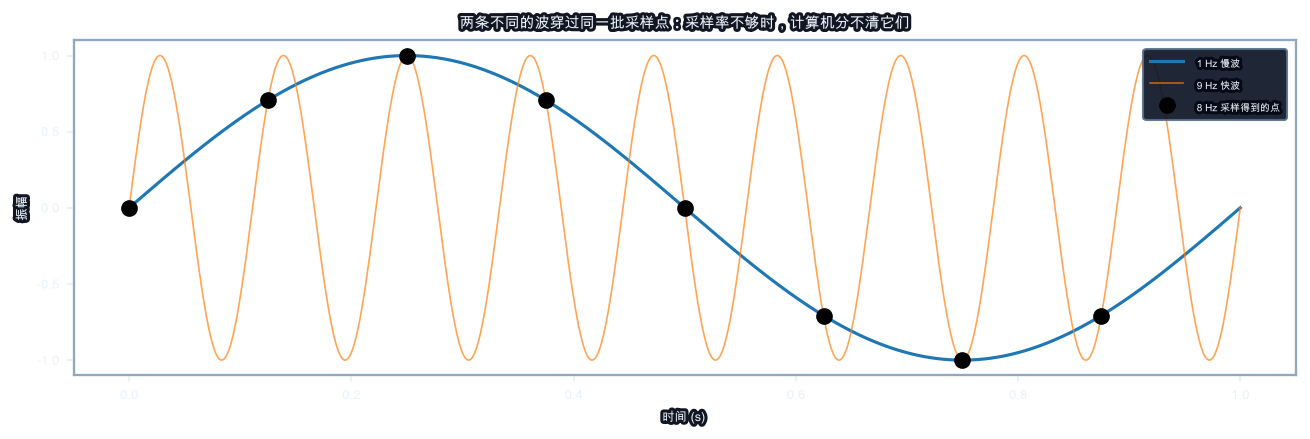

In [5]:
# 混叠（aliasing）预告：两条完全不同的波，穿过同一批采样点
import numpy as np
import matplotlib.pyplot as plt

sr = 8                        # 每秒只量 8 次
t_pts = np.arange(8) / sr     # 1 秒内的 8 个采样时刻

t_dense = np.linspace(0, 1, 1000)             # 用密集点近似"连续"曲线
slow = np.sin(2 * np.pi * 1 * t_dense)        # 1 Hz 慢波（在安全线内）
fast = np.sin(2 * np.pi * 9 * t_dense)        # 9 Hz 快波（远超 sr/2 = 4 Hz！）

plt.figure(figsize=(9, 3.2))
plt.plot(t_dense, slow, 'C0', lw=1.5, label='1 Hz 慢波')
plt.plot(t_dense, fast, 'C1', lw=0.8, alpha=0.7, label='9 Hz 快波')
plt.plot(t_pts, np.sin(2 * np.pi * 1 * t_pts), 'ko', ms=7, label='8 Hz 采样得到的点')
plt.xlabel('时间 (s)'); plt.ylabel('振幅')
plt.title('两条不同的波穿过同一批采样点：采样率不够时，计算机分不清它们')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

# 数值验证：9 Hz 快波在这 8 个时刻的取值，和 1 Hz 慢波一模一样
print('1 Hz 在采样点上的值:', np.round(np.sin(2 * np.pi * 1 * t_pts), 4))
print('9 Hz 在采样点上的值:', np.round(np.sin(2 * np.pi * 9 * t_pts), 4))
print('→ 完全相同！只看这 8 个数字，无法知道原来是哪条波。')
print('→ 这就是"每个周期至少要采 2 个点"的原因。完整实验见 L34（aliasing）。')

## ✏️ 任务 1：实现 `make_time_axis(duration, sample_rate)`

**第一步：手算**（duration=0.5, sr=8）

| 步骤 | 公式 | 结果 |
|---|---|---|
| 1. 算 N | `samples_count(0.5, 8)` | ✏️ ? |
| 2. 生成编号 n | `np.arange(N)` | ✏️ [?, ?, ?, ?] |
| 3. 转为时间 t | `n / sample_rate` | ✏️ [?, ?, ?, ?] |

**推理路线**（写完手算再看这里）：
1. N = `samples_count(duration, sample_rate)`
2. 编号 n = `np.arange(N)` → `[0, 1, 2, ..., N-1]`
3. 时间轴 t = n / sample_rate

返回：dtype=float64 的 numpy 数组，第一个元素为 0，最后一个 < duration。

---

**等一下——为什么"最后一个 < duration"？0.5 秒的信号，凭什么不量 t=0.5 那个点？**

这不是笔误，是刻意的设计，叫"**含头不含尾**"。两个理由：

1. **拼接不重复**。想象两段 0.5 秒的音频首尾相接：后一段的第一个点是它自己的 t=0，落在全局的 0.5 秒处。如果前一段也把 t=0.5 量进去，同一时刻就被记了两次。规定"每段只管 [0, duration) 这个左闭右开区间"，拼起来严丝合缝、不多不少。
2. **点数干净**。含头不含尾时点数恰好 N = duration × sr；如果两头都含，点数会变成 N+1，后面所有"一秒 = 44100 个数"的账都要多出一个零头。

打个比方：一根 0.5 米的萝卜每 0.125 米切一段，得到 4 段。采样点数的是"每一小段的**起点**"——0、0.125、0.25、0.375，恰好 4 个，最后一个起点必然小于 0.5。而 t=0.5 是**下一段**的第 0 个起点，归下一段管。

**常见坑（提前排雷）**：很多人的第一直觉是"0 到 0.5 平均分 N 个点"，写成 `np.linspace(0, duration, N)`——它两头都含，得到 [0, 0.167, 0.333, 0.5]，点与点的间隔变成 duration/(N-1) 而不是 1/sr，下面的断言会失败。请按推理路线用 `np.arange(N) / sample_rate`。

In [6]:
def make_time_axis(duration, sample_rate):
    # ✏️ TODO: 使用 samples_count + np.arange 实现
    raise NotImplementedError("TODO: 使用 samples_count + np.arange 实现")

In [7]:
try:
    import numpy as np

    t = make_time_axis(0.5, 8)
    assert isinstance(t, np.ndarray),          't 必须是 numpy 数组'
    assert t.shape == (4,),                    f'shape 应为 (4,)，得到 {t.shape}'
    assert np.allclose(t, [0.0, 0.125, 0.25, 0.375]), f'值不对：{t}'

    t2 = make_time_axis(1.0, 16000)
    assert t2.shape == (16000,)
    assert abs(t2[0]) < 1e-12,   '第一个时刻应为 0'
    assert t2[-1] < 1.0,         '最后一个时刻应 < duration（不含终点）'

    print('make_time_axis  OK')
    print(f'  t[:4] = {t}')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


## 插曲：数组形状（shape）

想象你订了一张电影票——你需要知道两件事：**排号**和**座位号**。
NumPy 数组也一样。`shape` 就是"座位票根"，告诉你这个数组有几排、每排几个。

| 比喻 | NumPy | 含义 |
|---|---|---|
| 一列数字（一排座位） | shape `(N,)` | 1维，N 个元素 |
| 矩阵（多排座位） | shape `(M, N)` | 2维，M 行 N 列 |
| 标量（VIP 票，不占排） | shape `()` | 0维，就是一个数 |

音频信号通常是 `shape (N,)`——就是一排 N 个采样值的序列。
后续 STFT 输出会是 `(n_frames, n_fft//2+1)`——变成了矩阵，时间在行，频率在列。

搞清楚 shape，就不会在矩阵乘法时迷路。

**30 秒口头题（不用写代码）**：`(16000,)` 和 `(1, 16000)` 哪个更像「单声道一段波形」？  
提示：前者是一排 16000 个采样点；后者是「1 行 × 16000 列」的矩阵写法——数值可以一样多，但**维数身份不同**，后面和矩阵/批数据打交道时要认清自己手里是哪一种。

In [8]:
try:
    import numpy as np

    scalar = np.float64(3.14)
    vec    = np.array([0., 0.5, 1.])
    mat    = np.array([[1, 2], [3, 4]])

    for name, arr in [('标量', scalar), ('向量', vec), ('矩阵', mat)]:
        print(f'  {name:4s}  shape={str(arr.shape):10s}  ndim={arr.ndim}  dtype={arr.dtype}')

    # 音频信号的形状
    t = make_time_axis(1.0, 16000)
    print(f'\n  音频时间轴  shape={t.shape}  → 一维，{len(t)} 个点')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

  标量    shape=()          ndim=0  dtype=float64
  向量    shape=(3,)        ndim=1  dtype=float64
  矩阵    shape=(2, 2)      ndim=2  dtype=int64
⬜ 请先完成上面的 TODO 函数，再运行本演示格


## ✏️ 任务 2：实现 `make_sine(duration, sample_rate, frequency, amplitude=1.0)`

**先搭个桥：公式里的 2π 是从哪冒出来的？（不背，推一遍）**

把正弦波想成摩天轮上的一个座舱：座舱匀速转圈，`sin` 报出的就是它此刻的**高度**。数学上，转满**一整圈**记作 2π 弧度——这是 sin 的"一圈"的官方长度，sin 每过 2π 就重复一次。

现在三步推出公式：

1. `frequency = f` 的意思是：座舱**每秒转 f 圈**；
2. 那么到 t 秒为止，一共转了 f × t 圈；
3. 每圈是 2π 弧度，所以总角度 θ = 2π × f × t 弧度。

把这个角度喂给 sin，再乘上振幅（amplitude，A） A（摩天轮的半径），就得到：

**公式**：`x(t) = amplitude × sin(2π × frequency × t)`

自查一下频率对不对：t 从 0 走到 1 秒，θ 从 0 走到 2πf，恰好完成 f 个完整周期——正是"每秒振动 f 次"。所以 2π 不是装饰，它是"**圈数 → 弧度**"的换算系数；去掉它，"每秒 f 圈"就变成了"每秒 f/(2π) 圈"，频率全错。

**弧度急救包（填手算表前必读）**：弧度和角度的换算是 **π rad = 180°**。下表 θ 列的小数看着吓人，其实全是高中背过的特殊角——千万别把 0.785 当成"0.785 度"去算（sin 0.785° ≈ 0.014，会和答案差几十倍）：

| θ（弧度小数）| = π 的几分之几 | = 多少度 | sin θ |
|---|---|---|---|
| 0.000 | 0 | 0° | 0 |
| 0.785 | π/4 | 45° | √2/2 ≈ 0.71 |
| 1.571 | π/2 | 90° | 1 |
| 2.356 | 3π/4 | 135° | √2/2 ≈ 0.71 |

**第一步：手算**（duration=0.5s, sr=8Hz, freq=1Hz, A=1）

| n | t = n/sr (s) | θ = 2π·f·t (rad) | θ 换算（**已算好，你只填 sin 列**） | sin(θ)（精确到小数点后 2 位）|
|---|---|---|---|---|
| 0 | 0.000 | 0.000 | 0 = 0° | ✏️ ? |
| 1 | 0.125 | 0.785 | π/4 = 45° | ✏️ ? |
| 2 | 0.250 | 1.571 | π/2 = 90° | ✏️ ? |
| 3 | 0.375 | 2.356 | 3π/4 = 135° | ✏️ ? |

**推理路线**：
1. 用 `make_time_axis` 生成时间轴 t
2. 返回 `amplitude × np.sin(2 × np.pi × frequency × t)`

In [9]:
def make_sine(duration, sample_rate, frequency, amplitude=1.0):
    # ✏️ TODO: 使用 make_time_axis 和 np.sin 实现
    raise NotImplementedError("TODO: 使用 make_time_axis 和 np.sin 实现")

In [10]:
try:
    import numpy as np

    # 基本验证
    x = make_sine(1.0, 16, 2.0)
    assert isinstance(x, np.ndarray)
    assert x.shape == (16,)
    assert abs(x.max() - 1.0) < 1e-9,   f'max 应为 1.0，得到 {x.max()}'
    assert abs(x.min() + 1.0) < 1e-9,   f'min 应为 -1.0，得到 {x.min()}'

    # 振幅验证
    x2 = make_sine(1.0, 16, 2.0, amplitude=3.0)
    assert abs(x2.max() - 3.0) < 1e-9,  f'amplitude=3 时 max 应为 3.0'

    # 与 numpy 参考一致
    t = make_time_axis(1.0, 16)
    ref = np.sin(2 * np.pi * 2.0 * t)
    assert np.allclose(x, ref), '结果与 np.sin 参考不一致'

    # 对照手算：duration=0.5, sr=8, freq=1
    x_check = make_sine(0.5, 8, 1.0)
    print('手算对照（freq=1Hz, sr=8Hz, duration=0.5s）：')
    print(f'  代码输出 = {np.round(x_check, 3)}')
    print(f'  参考值   = {np.round(np.sin([0, np.pi/4, np.pi/2, 3*np.pi/4]), 3)}')
    print('make_sine  OK')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


In [11]:
import matplotlib.pyplot as plt

sr, dur = 200, 1.0
try:
    t = make_time_axis(dur, sr)
    fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
    for ax, freq, color in zip(axes, [2, 5, 10], ['C0', 'C1', 'C2']):
        ax.plot(t, make_sine(dur, sr, freq), color=color)
        ax.set_ylabel(f'{freq} Hz'); ax.set_ylim(-1.3, 1.3); ax.grid(alpha=0.3)
    axes[-1].set_xlabel('时间 (s)')
    fig.suptitle('频率越高，单位时间内波峰越多')
    plt.tight_layout(); plt.show()
except (NotImplementedError, TypeError):
    print('⬜ 请先完成 make_time_axis / make_sine，再运行本演示格')
else:
    try:
        from IPython.display import Audio, display
        x_audio = make_sine(1.5, 16000, 440)
        print('播放 440 Hz（A4 音）——你将听到标准「啦」音')
        display(Audio(x_audio, rate=16000))
    except Exception:
        print('（非 Jupyter 环境，跳过播放）')

⬜ 请先完成 make_time_axis / make_sine，再运行本演示格


## 参数实验：频率与音高（pitch）

**预测问题（先回答，再运行验证）**：
- `make_sine(1.0, 16000, 880)` 的最大值是多少？（忽略浮点毛刺：理论最大值 = amplitude，默认 1.0）
- 和 `make_sine(1.0, 16000, 440)` 的 shape 一样吗？
- 哪个频率听起来音调更高？

音高由频率决定。频率加倍 = 升高一个八度：

| 音名 | 频率 |
|---|---|
| A3（低八度）| 220 Hz |
| A4（标准「啦」）| 440 Hz |
| A5（高八度）| 880 Hz |

In [12]:
try:
    from IPython.display import Audio, display
    sr = 16000
    for name, freq in [('A3 (220 Hz)', 220), ('A4 (440 Hz)', 440), ('A5 (880 Hz)', 880)]:
        wave = make_sine(1.0, sr, freq)
        print(f'{name}  shape={wave.shape}  max={wave.max():.3f}')
        display(Audio(wave, rate=sr))
except (NotImplementedError, TypeError):
    print('⬜ 请先完成 make_sine，再运行本格')
except Exception:
    sr = 16000
    for name, freq in [('A3', 220), ('A4', 440), ('A5', 880)]:
        wave = make_sine(1.0, sr, freq)
        print(f'{name}  shape={wave.shape}  max={wave.max():.3f}')

⬜ 请先完成 make_sine，再运行本格


## 铺垫：RMS 到底在量什么？为什么不直接取平均？

马上要实现的 `signal_summary` 里有个新面孔：**RMS（Root Mean Square，均方根）**。先讲人话，再给公式。

**它想回答的问题：这段声音"平均有多响"？**

第一直觉是取平均值（mean）——但正弦波一半时间在正、一半时间在负，加起来正负抵消，mean ≈ 0。响 100 分贝的音乐和一片寂静，mean 都是 0，这个尺子量不出响度。因为响度关心的是"离 0 有多远"，不关心是正是负。

于是分三步走：先**平方**（Square，把负的也变成正的，顺便放大大振幅的贡献），再**平均**（Mean），最后**开根号**（Root，把单位从"振幅的平方"变回"振幅"）。写成公式就是：

RMS = √( mean(x²) )

名字 Root-Mean-Square 就是这三步倒着念。RMS 大致对应耳朵感受到的**平均响度/能量**，L40（频谱）和 L51（真实音频）都会用它当尺子。

**那"纯正弦波 RMS = A/√2"这个提示是哪来的？**

关键一步：看 **sin² 长什么样**（下一格会画出来）。sin 在 -1 和 +1 之间摆；平方之后，sin² 在 0 和 1 之间摆，而且形状**关于高度 1/2 上下对称**——高于 1/2 的"山"和低于 1/2 的"谷"面积一样多。所以不用积分也能看出：**sin² 的平均值恰好是 1/2**。代入 RMS 公式：

RMS = √( mean(A²·sin²) ) = √( A² × 1/2 ) = A/√2 ≈ 0.707 × A

这就是那个 √2 的来历——它不是魔法数，是"sin² 平均是一半"开了个根号。（严格证明要用积分，后续课程会碰到；但"上下对称、面积各半"这幅图已经足够支撑白板推导。）

还有一个疑点要拆掉：待会儿的手算例子只有 4 个点 [0, 1, 0, -1]，算出 0.707 会不会只是巧合？下一格用代码验证：**频率、采样率、时长随便换，RMS 都钉在 0.707·A 附近**——只要覆盖大致完整的周期，点取多取少都不影响。

理论值 1/√2 = 0.7071
  freq=   1 Hz, sr=     8, dur=1.0s → RMS = 0.7071
  freq=   3 Hz, sr=   100, dur=1.0s → RMS = 0.7071
  freq= 440 Hz, sr=  8000, dur=0.5s → RMS = 0.7071
  freq=   7 Hz, sr= 44100, dur=0.3s → RMS = 0.6942
→ 最后一行不是整数个周期，所以略偏；周期越完整，越贴近 0.7071。


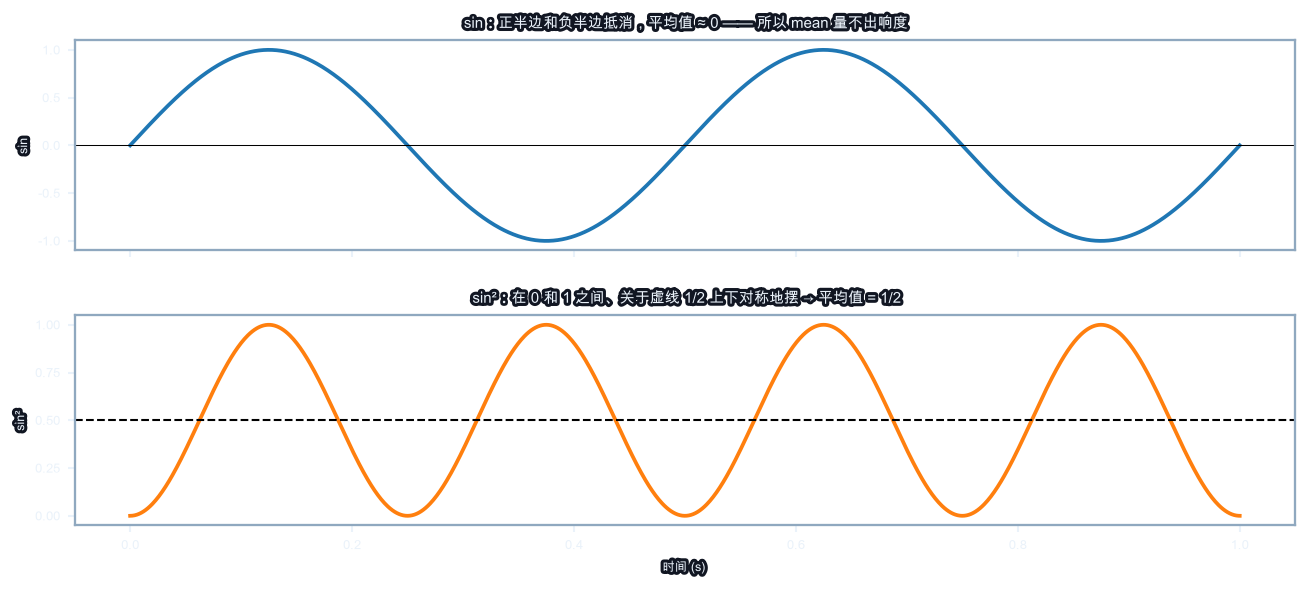

In [13]:
# 眼见为实：sin² 的平均高度就是 1/2，所以任何纯正弦波 RMS ≈ A/√2
# （本格不依赖你实现的函数，随时可以运行）
import numpy as np
import matplotlib.pyplot as plt

t_dense = np.linspace(0, 1, 1000)
s  = np.sin(2 * np.pi * 2 * t_dense)   # 2 Hz 正弦波
s2 = s ** 2                            # 它的平方

fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
axes[0].plot(t_dense, s, 'C0'); axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_ylabel('sin')
axes[0].set_title('sin：正半边和负半边抵消，平均值 ≈ 0 —— 所以 mean 量不出响度')
axes[1].plot(t_dense, s2, 'C1'); axes[1].axhline(0.5, color='k', ls='--', lw=1)
axes[1].set_ylabel('sin²'); axes[1].set_xlabel('时间 (s)')
axes[1].set_title('sin²：在 0 和 1 之间、关于虚线 1/2 上下对称地摆 → 平均值 = 1/2')
plt.tight_layout(); plt.show()

# 不是 4 个点的巧合：频率/采样率/时长随便换，RMS 都钉在 A/√2 附近
print(f'理论值 1/√2 = {1/np.sqrt(2):.4f}')
for freq, sr_i, dur in [(1, 8, 1.0), (3, 100, 1.0), (440, 8000, 0.5), (7, 44100, 0.3)]:
    tt = np.arange(round(dur * sr_i)) / sr_i
    x = np.sin(2 * np.pi * freq * tt)
    rms = np.sqrt(np.mean(x ** 2))
    print(f'  freq={freq:>4} Hz, sr={sr_i:>6}, dur={dur}s → RMS = {rms:.4f}')
print('→ 最后一行不是整数个周期，所以略偏；周期越完整，越贴近 0.7071。')

## ✏️ 任务 3：实现 `signal_summary(x)`

返回字典，包含信号的统计摘要：
- `length`：数组长度（整数）
- `shape`：数组形状（元组）
- `max_abs`：最大绝对值（浮点数）
- `mean`：均值（浮点数）
- `rms`：均方根（Root Mean Square）= √(mean(x²))（浮点数）

**手算**（x = make_sine(1.0, 4, 1.0)，即 4 个点：[0, 1, 0, -1]）：

| 键 | 公式 | 手算 |
|---|---|---|
| length | `len(x)` | ✏️ ? |
| shape | `x.shape` | ✏️ ? |
| max_abs | `max(|0|,|1|,|0|,|-1|)` | ✏️ ? |
| mean | `(0+1+0-1)/4` | ✏️ ? |
| rms | `√((0²+1²+0²+1²)/4)` | ✏️ ?（提示：纯正弦波 RMS = A/√2）|

In [14]:
def signal_summary(x):
    # ✏️ TODO: 返回包含以下键的字典
    #   length  : len(x)
    #   shape   : x.shape
    #   max_abs : np.max(np.abs(x))
    #   mean    : float(np.mean(x))
    #   rms     : float(np.sqrt(np.mean(x**2)))  ← 均方根，白板挑战 Q4 会用到
    raise NotImplementedError("TODO: 返回含 length/shape/max_abs/mean/rms 的字典")

In [15]:
try:
    import numpy as np

    x_test = make_sine(1.0, 64, 3.0)
    s = signal_summary(x_test)

    assert s.get('length') == 64,                    f"length 应为 64，得到 {s.get('length')}"
    assert s.get('shape') == (64,),                  f"shape 应为 (64,)，得到 {s.get('shape')}"
    assert abs(s.get('max_abs', 0) - 1.0) < 0.02,   f"max_abs 应约为 1.0"
    assert abs(s.get('mean', 1)) < 0.05,             f"均值应接近 0"
    assert abs(s.get('rms', 0) - 1/np.sqrt(2)) < 0.02, f"rms 应约为 1/√2 ≈ 0.707"

    # 手算验证：[0, 1, 0, -1] 的 4 个点
    x4 = make_sine(1.0, 4, 1.0)
    s4 = signal_summary(x4)
    print('手算对照（4 个点 [0, 1, 0, -1]）：')
    print(f'  x4     = {np.round(x4, 3)}')
    print(f'  summary = {s4}')
    print()
    print('signal_summary  OK')
    print(f'  rms 实测={s["rms"]:.4f}  理论值 1/√2={1/np.sqrt(2):.4f}')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


### 📦 小方框：手算是 0，屏幕却是 5.551115123125783e-17——你没写错！

上一格的打印里，`mean` 那一项多半不是干净的 0，而是 `5.551115123125783e-17` 这样一长串。如果你正在怀疑自己函数写错了——停，先看两件事：

**第一件：这个写法怎么读。** `e-17` 是**科学计数法**的键盘写法：`5.55e-17` = 5.55 × 10⁻¹⁷ = 0.0000000000000000555（小数点后 16 个零再跟 555）。它比一粒尘埃相对地球还小，本质就是 0。

**第二件：它为什么不是 0。** 计算机用二进制存小数，很多十进制小数根本存不"整"（就像 1/3 在十进制里写不完：0.3333…），于是每次运算都带着**极微小的舍入误差**。你手算的精确 0，到了计算机里就成了"离 0 只差 10⁻¹⁷ 的数"。

**结论：看到 e-15、e-16、e-17 这种量级，读作 0——这恰恰说明你算对了。**

这也解释了本课所有对答案断言的写法：一律用 `abs(...) < 很小的容差` 或 `np.isclose`，从不用 `==`。手算和代码"对答案"，对的是"足够接近"，不是"每一位都相同"。

顺带排掉两个同款惊吓，之后见到不要慌：
- 打印里偶尔冒出 `-0.`（"负零"？！）：就是 0 从负方向舍入过来，带了个可以忽略的负号；
- 稍后的白板挑战 Q3，若你推出的精确答案是 0，程序会打印 `-0.000000` 或 `-1.5e-15`——同一回事，都算你对。

下一格亲手戳一下这个误差。

In [16]:
# 亲手戳一下浮点误差（本格不依赖你实现的函数，随时可以运行）
import numpy as np

print('0.1 + 0.2 =', repr(0.1 + 0.2), '  ← 竟然不是 0.3！')
print('0.1 + 0.2 == 0.3 ?          ', 0.1 + 0.2 == 0.3)
print('np.isclose(0.1 + 0.2, 0.3) ?', np.isclose(0.1 + 0.2, 0.3))
print()
print('sin(π) 理论上 = 0，计算机给出:', np.sin(np.pi), ' ← e-16 量级，读作 0')
print()
print('→ 所以"对答案"永远用 np.isclose / 容差，绝不用 ==。')

0.1 + 0.2 = 0.30000000000000004   ← 竟然不是 0.3！
0.1 + 0.2 == 0.3 ?           False
np.isclose(0.1 + 0.2, 0.3) ? True

sin(π) 理论上 = 0，计算机给出: 1.2246467991473532e-16  ← e-16 量级，读作 0

→ 所以"对答案"永远用 np.isclose / 容差，绝不用 ==。


## NumPy 三要素：dtype / 广播 / 切片

L32–L51 的 DSP 代码大量用到三个 NumPy 机制。这里用声音信号演示，为后续做铺垫。

**先扫清两个词：bit 和字节（byte）**

计算机的底层只有"开关"：开 = 1，关 = 0。一个开关叫 1 个 **bit（位/比特）**。8 个开关打包成一组，叫 1 个**字节（byte）**——这是内存的基本计量单位，就像"打"之于鸡蛋（1 打 = 12 个）。

有了这两个词，dtype 名字里的数字就直接告诉你开销了：

- float**64**：用 64 个开关存一个小数 → 64 ÷ 8 = **8 字节**
- float**32**：用 32 个开关存一个小数 → 32 ÷ 8 = **4 字节**

开关越多，能表示的小数越精细；但占的内存也成倍增加。下一格会用到三个新名词，先备好小词典：

| 写法 | 含义 |
|---|---|
| `arr.itemsize` | 数组里**每个元素**占几个字节 |
| `arr.nbytes` | **整个数组**总共占几个字节（= itemsize × 元素个数）|
| `arr.astype(np.float32)` | 把数组换一种精度重存一遍（64 开关 → 32 开关）|


In [17]:
try:
    # ── dtype：float64 vs float32 ──────────────────────────────────────
    # 音频处理两种常见精度
    a64 = np.zeros(8, dtype=np.float64)
    a32 = np.zeros(8, dtype=np.float32)
    print(f'float64 每元素 {a64.itemsize} 字节，float32 每元素 {a32.itemsize} 字节')
    print(f'float64 占用 {a64.nbytes} 字节  →  float32 占用 {a32.nbytes} 字节（省一半内存）')

    # make_sine 默认生成 float64；转换到 float32：
    t = make_time_axis(0.5, 8)
    x64 = np.sin(2 * np.pi * 1.0 * t)           # float64，默认
    x32 = x64.astype(np.float32)                  # float32，深度学习常用
    print(f'\nmake_time_axis → dtype={x64.dtype},  转 float32 后 dtype={x32.dtype}')
    print(f'精度差：max |x64 - x32| = {np.abs(x64 - x32.astype(np.float64)).max():.2e}')
    # 为何音频通常用 float32？内存减半，GPU/神经网络原生支持；精度对人耳足够。

except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

float64 每元素 8 字节，float32 每元素 4 字节
float64 占用 64 字节  →  float32 占用 32 字节（省一半内存）
⬜ 请先完成上面的 TODO 函数，再运行本演示格


In [18]:
try:
    # ── 广播（broadcasting）：叠加两路正弦波 ────────────────────────
    # 标量乘数组：NumPy 自动将标量广播到每个元素
    t = make_time_axis(1.0, 16)
    wave_A = 0.7 * np.sin(2 * np.pi * 1.0 * t)  # 0.7 是标量，广播到 16 个元素
    wave_B = 0.3 * np.sin(2 * np.pi * 3.0 * t)

    # 两路信号相加：shape (16,) + shape (16,) → shape (16,)
    mixed = wave_A + wave_B
    print(f'wave_A.shape={wave_A.shape}, wave_B.shape={wave_B.shape} → mixed.shape={mixed.shape}')

    # 多路信号堆叠为矩阵（行=通道，列=时间）
    multi = np.stack([wave_A, wave_B, mixed])      # shape (3, 16)
    print(f'堆叠后 multi.shape={multi.shape}  （3 个通道 × 16 个采样点）')
    assert mixed.shape == (16,)
    assert multi.shape == (3, 16)
    print('✓ 广播与堆叠形状正确')

except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


In [19]:
try:
    # ── 切片（slicing）：截取与降采样 ───────────────────────────────
    sr_demo, dur_demo = 8, 2.0                     # 8 Hz，2 秒，共 16 点
    x = make_sine(dur_demo, sr_demo, 1.0)
    print(f'完整信号 x.shape={x.shape}  →  {x.round(2)}')

    # 切片 1：截取第 1 秒（索引 sr : 2*sr）
    x_sec1 = x[sr_demo : 2 * sr_demo]
    print(f'第 1 秒  x[{sr_demo}:{2*sr_demo}].shape={x_sec1.shape}  →  {x_sec1.round(2)}')

    # 切片 2：降采样（每隔一点取一点 → 采样率减半）
    x_down = x[::2]
    print(f'降采样  x[::2].shape={x_down.shape}  →  {x_down.round(2)}')

    assert x_sec1.shape == (sr_demo,), f'期望 ({sr_demo},)，得到 {x_sec1.shape}'
    assert x_down.shape == (sr_demo,), f'期望 ({sr_demo},)，得到 {x_down.shape}'
    print('✓ 切片形状正确')

except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


## Aurora 连接

**先说正向的一句**：今天这四个函数是你自己的**工具箱**——你在 notebook 里实现、用 assert 钉牢；后面 L32–L37 会反复调用同一套直觉。

它们与 Aurora Audio Core 的频域管线在**概念上**对齐，但**不是** `transforms.py` 里的现成 API（仓库里的 `transforms.py` 是 dft/fft/stft 等频域核，接口不同）：

| 本课函数 | 概念对应 | 说明 |
|---|---|---|
| `samples_count` | 帧长 / 采样点数 | 所有信号函数的第一步 |
| `make_time_axis` | `t[n]=n/sr` | L32 会再次建立时间轴 |
| `make_sine` | 正弦波生成 | L33–L37 反复使用 |
| `signal_summary` | 信号统计摘要 | L40、L51 会读 RMS 等量 |

> 因此不要写 `from aurora.audio.transforms import make_sine`——那边没有这个学生版入口。  
> L32（`notebooks/5_audio_dsp/L32_numpy_signals.ipynb`）会复用本课直觉，把「采样点 + 时间坐标」搭成完整信号地基。


## ✏️ 白板挑战：不看代码，纸上推导（目标 10 分钟）

这是你学完本课后的闭卷自测。**盖上屏幕**，在纸上完成以下推导：

---

**题目**：信号参数如下
- 采样率 `sr = 8000` Hz（电话音质）
- 时长 `duration = 0.5` 秒
- 频率 `freq = 440` Hz（A4 音）
- 振幅 $A = 0.7$（代码参数名 `amplitude`）

**问 1**：数组 `x` 有多少个元素？（写出公式）

**问 2**：`t[100]` 等于多少秒？（`t` 是时间轴数组）

**问 3**：`x[100]` 的值是多少？（用 `sin` 表示，不用算出精确值）

**问 4**：`signal_summary(x)['rms']` 的理论值是多少？
提示：纯正弦波 `A·sin(...)` 的 RMS = A / √2（为什么是 √2？回看任务 3 前"sin² 平均是 1/2"那一节）

---

推导完成后运行下面的验证格对答案。

> **Q3 的彩蛋（推完再看）**：如果你把角度算到底——2π × 440 × 0.0125 = 11π，而 sin 在 π 的整数倍处恰好为 0——那么你的纸面答案是精确的 0。验证格打印出 `-0.000000` 或 `-1.5e-15` 之类的数？那是浮点误差版的 0（见任务 3 后的小方框），说明你推对了，而且推得比计算机还准。

In [20]:
try:
    # ✏️ 对答案格——先完成白板推导再运行
    import numpy as np

    sr, duration, freq, amplitude = 8000, 0.5, 440, 0.7

    # 问1：元素个数
    N_expected = round(duration * sr)
    t = make_time_axis(duration, sr)
    x = make_sine(duration, sr, freq, amplitude)
    assert len(x) == N_expected, f"Q1: 期望 {N_expected}，实际 {len(x)}"
    print(f"Q1 ✅  N = round({duration} × {sr}) = {N_expected} 个采样点")

    # 问2：t[100]
    t100_expected = 100 / sr
    assert np.isclose(t[100], t100_expected, atol=1e-10), f"Q2: 期望 {t100_expected:.6f}，实际 {t[100]:.6f}"
    print(f"Q2 ✅  t[100] = 100 / {sr} = {t100_expected:.6f} 秒")

    # 问3：x[100]
    x100_expected = amplitude * np.sin(2 * np.pi * freq * t[100])
    assert np.isclose(x[100], x100_expected, atol=1e-10)
    print(f"Q3 ✅  x[100] = {amplitude} × sin(2π × {freq} × {t100_expected:.6f}) = {x100_expected:.6f}")

    # 问4：RMS 理论值
    rms_theory = amplitude / np.sqrt(2)
    s = signal_summary(x)
    assert np.isclose(s['rms'], rms_theory, atol=0.01), f"Q4: 理论 {rms_theory:.4f}，实际 {s['rms']:.4f}"
    print(f"Q4 ✅  RMS ≈ {amplitude}/√2 = {rms_theory:.4f}  实测 {s['rms']:.4f}")
    print()
    print("🎉 白板挑战通过！你对采样、时间轴、正弦波的计算已经内化。")
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 函数，再运行本演示格')

⬜ 请先完成上面的 TODO 函数，再运行本演示格


## 本课收束

| 函数 | 作用 | 后续出现 |
|---|---|---|
| `samples_count` | N = duration × sr | 每个信号函数的第一步 |
| `make_time_axis` | 生成时间轴 | L32 numpy_signals, L33 sine_wave |
| `make_sine` | 生成正弦波 | L34 aliasing, L36 windows, L37 DFT |
| `signal_summary` | 汇总统计量 | L40 spectrum, L51 real_audio |

**本课用到的方法论**：先手算推导表，再写代码对答案。
这个方法贯穿整个 Aurora 课程——FFT 的每一步也会先手算再实现。

**核心直觉**：声音 = 一维 float64 数组，长度 = duration × sample_rate。
FFT 把这个数组变换到频域（frequency domain）——那是 L37 以后的事。

**下一课 L03**：还不学「怎么算」FFT——先学会**读**时频图（谱图）长什么样。
你将看到纯音 / 和弦 / 扫频 / 噪声的时频图，为 L37–L41 种下视觉直觉。

In [ ]:
# ✏️ 本课自评
l02_review = {
    "samples_count_done":   None,  # samples_count 实现并通过断言？True/False
    "make_time_axis_done":  None,  # make_time_axis 实现并通过断言？True/False
    "make_sine_done":       None,  # make_sine 实现并通过断言？True/False
    "signal_summary_done":  None,  # signal_summary 实现并通过断言？True/False
    "whiteboard_passed":    None,  # 白板挑战（纸上推导）完成？True/False
    "sampling_rate_intuition": None,  # 能解释为什么 sr=44100 而不是 44000？True/False
    #   ↑ 两问合一：(a) 为什么必须 > 40000（奈奎斯特：每周期至少 2 个点）；
    #     (b) 为什么偏偏是 44100（历史：借录像机磁带存音频，NTSC/PAL 都凑出 44100）。
    #     答案都在第 1 节"追问一/追问二"，答不上来回去重读那两小节即可。
}

unfilled = [k for k, v in l02_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l02_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
    print('   建议：重新阅读对应章节，用手算而不是运行代码来验证理解。')
else:
    print('✅ L02 全部通关！进入 L03：谱图直觉')

---

→ **下一课**　[L03 · 谱图直觉](L03_spectrogram.ipynb)

> 下节课将学习 **谱图直觉**：在学 FFT 之前先读懂时频图的三个轴。